In [15]:
#importation des modules
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split   
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset


In [27]:
#génération des données équilibrées

#standardisation de la transformation des images pour coller au modèle restnet18
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
data_set=ImageFolder(root=".\\MINI-DDSM-Complete-JPEG-81", transform=transform)
label=np.array(data_set.targets)
print(label)

numero_random=1
train_size=0.7
val_size=0.15
test_size=0.15

sss1=StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=numero_random)
for train_val_index, test_index in sss1.split(np.zeros(len(label)), label):
    train_val_indices=train_val_index
    test_indices=test_index

train_val_labels=label[train_val_indices]
print(train_val_labels)

new_val_size=val_size/(train_size+val_size)
ss2=StratifiedShuffleSplit(n_splits=1, test_size=new_val_size, random_state=numero_random)
for train_index, val_index in ss2.split(np.zeros(len(train_val_labels)), train_val_labels):
    train_indices=train_val_indices[train_index]
    val_indices=train_val_indices[val_index]


train_set=Subset(data_set, train_indices)
val_set=Subset(data_set, val_indices)
test_set=Subset(data_set, test_indices)

print(f"Train set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")

bs=64
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True)
print("train_loader ok")
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False)
print("val_loader ok")
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False)
print("test_loader ok")


[0 0 0 ... 2 2 2]
[0 1 1 ... 1 2 2]
Train set size: 1338
Validation set size: 287
Test set size: 287
train_loader ok
val_loader ok
test_loader ok


In [ ]:
#importation du modèle (ResNet18 pré-entraîné ou non)
#model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model=models.resnet18(weights=None)
model.fc = torch.nn.Linear(512,3)
model.load_state_dict(torch.load("best_resnet18_model.pth"))


#définition du nombre de classes, ici 3 : cancer, bénin, normal
num_class=3
model.fc = torch.nn.Linear(model.fc.in_features, num_class)

#choix fonction de perte et de l'optimiseur
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001) 

#définition de l'appareil d'entraînement (GPU si dispo)
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
#entraînement du modèle
num_epochs=5

def train_model(model, train_loader, val_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss= running_loss / len(train_loader.dataset)
    return(epoch_loss)

def validate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    corrects = 0.0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _,preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss / len(val_loader.dataset)
        epoch_acc = corrects.double() / len(val_loader.dataset)
        return(epoch_loss, epoch_acc)
    


def entrain_and_validate():
    best_acc=0.0
    for epoch in range(num_epochs):
        print(f"\n--- Époque {epoch+1}/{num_epochs} ---")

        train_loss=train_model(model, train_loader, val_loader, criterion, optimizer)
        print(f"Loss d'entraînement: {train_loss:.4f}")

        val_loss, val_acc=validate_model(model, val_loader, criterion, device)
        print(f"Loss de validation: {val_loss:.4f} | Accuracy de validation: {val_acc:.4f}")

        if best_acc < val_acc:
            best_acc=val_acc
            torch.save(model.state_dict(), "best_resnet18_model.pth")
            print("Modèle sauvegardé.")

    print("\nEntraînement terminé.")

entrain_and_validate()



--- Époque 1/5 ---


Training:   0%|          | 0/21 [00:00<?, ?it/s]

Training: 100%|██████████| 21/21 [01:57<00:00,  5.58s/it]


Loss d'entraînement: 0.2480


Validating: 100%|██████████| 5/5 [00:24<00:00,  4.95s/it]


...

Loss de validation: 0.6614 | Accuracy de validation: 0.7108

--- Époque 5/5 ---


Training: 100%|██████████| 21/21 [01:49<00:00,  5.22s/it]


Loss d'entraînement: 0.1306


Validating: 100%|██████████| 5/5 [00:19<00:00,  3.90s/it]

Loss de validation: 0.6706 | Accuracy de validation: 0.7073

Entraînement terminé.


In [36]:
#extraction des résultats sur test set
import torch.nn.functional as F

model.eval()

all_predictions = []
all_labels= []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        probabilities = F.softmax(outputs, dim=1)
        _,preds=torch.max(outputs,1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        # Traitez les probabilités comme nécessaire

predictions_np=np.array(all_predictions)
labels_np=np.array(all_labels)

accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')


100%|██████████| 5/5 [00:25<00:00,  5.08s/it]

Test_Accuracy : 69.3380%


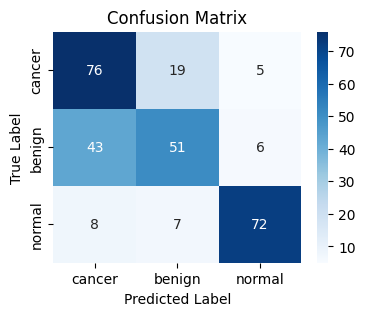

In [37]:
#matrice de confusion

class_names = ['cancer', 'benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



In [38]:

report = classification_report(labels_np, predictions_np, target_names=class_names)
print("rapport de classification : ")
print(report)

rapport de classification : 
              precision    recall  f1-score   support

      cancer       0.60      0.76      0.67       100
      benign       0.66      0.51      0.58       100
      normal       0.87      0.83      0.85        87

    accuracy                           0.69       287
   macro avg       0.71      0.70      0.70       287
weighted avg       0.70      0.69      0.69       287



In [ ]:
#visualisations d'exemples spécifiques
misclassified_indices = np.where(predictions_np != labels_np)[0]
#revenir en arrière pour afficher des images mal classées si besoin, à voir plus en détail...